## PARTIE 0 — ÉTAPE 1 Chargement des bases de données

In [57]:
import pandas as pd

basics = pd.read_csv(
    "title.basics.tsv",
    sep="\t",
    na_values="\\N",
    dtype=str
)

ratings = pd.read_csv(
    "title.ratings.tsv",
    sep="\t",
    na_values="\\N"
)

print(basics.head())
print(ratings.head())

      tconst titleType            primaryTitle           originalTitle  \
0  tt0000001     short              Carmencita              Carmencita   
1  tt0000002     short  Le clown et ses chiens  Le clown et ses chiens   
2  tt0000003     short            Poor Pierrot          Pauvre Pierrot   
3  tt0000004     short             Un bon bock             Un bon bock   
4  tt0000005     short        Blacksmith Scene        Blacksmith Scene   

  isAdult startYear endYear runtimeMinutes                    genres  
0       0      1894     NaN              1         Documentary,Short  
1       0      1892     NaN              5           Animation,Short  
2       0      1892     NaN              5  Animation,Comedy,Romance  
3       0      1892     NaN             12           Animation,Short  
4       0      1893     NaN              1                     Short  
      tconst  averageRating  numVotes
0  tt0000001            5.7      2213
1  tt0000002            5.5       317
2  tt0000003   

In [58]:
print(basics.head())
print(ratings.head())

      tconst titleType            primaryTitle           originalTitle  \
0  tt0000001     short              Carmencita              Carmencita   
1  tt0000002     short  Le clown et ses chiens  Le clown et ses chiens   
2  tt0000003     short            Poor Pierrot          Pauvre Pierrot   
3  tt0000004     short             Un bon bock             Un bon bock   
4  tt0000005     short        Blacksmith Scene        Blacksmith Scene   

  isAdult startYear endYear runtimeMinutes                    genres  
0       0      1894     NaN              1         Documentary,Short  
1       0      1892     NaN              5           Animation,Short  
2       0      1892     NaN              5  Animation,Comedy,Romance  
3       0      1892     NaN             12           Animation,Short  
4       0      1893     NaN              1                     Short  
      tconst  averageRating  numVotes
0  tt0000001            5.7      2213
1  tt0000002            5.5       317
2  tt0000003   

ÉTAPE 2 — FUSION DES DONNÉES

In [59]:
df = pd.merge(basics, ratings, on="tconst")

In [60]:
print(df.head())

      tconst titleType            primaryTitle           originalTitle  \
0  tt0000001     short              Carmencita              Carmencita   
1  tt0000002     short  Le clown et ses chiens  Le clown et ses chiens   
2  tt0000003     short            Poor Pierrot          Pauvre Pierrot   
3  tt0000004     short             Un bon bock             Un bon bock   
4  tt0000005     short        Blacksmith Scene        Blacksmith Scene   

  isAdult startYear endYear runtimeMinutes                    genres  \
0       0      1894     NaN              1         Documentary,Short   
1       0      1892     NaN              5           Animation,Short   
2       0      1892     NaN              5  Animation,Comedy,Romance   
3       0      1892     NaN             12           Animation,Short   
4       0      1893     NaN              1                     Short   

   averageRating  numVotes  
0            5.7      2213  
1            5.5       317  
2            6.4      2325  
3     

In [61]:
df = df[df['titleType'] == 'movie']

In [62]:
print(df.head())

        tconst titleType                   primaryTitle  \
8    tt0000009     movie                     Miss Jerry   
144  tt0000147     movie  The Corbett-Fitzsimmons Fight   
484  tt0000502     movie                       Bohemios   
543  tt0000574     movie    The Story of the Kelly Gang   
556  tt0000591     movie               The Prodigal Son   

                     originalTitle isAdult startYear endYear runtimeMinutes  \
8                       Miss Jerry       0      1894     NaN             45   
144  The Corbett-Fitzsimmons Fight       0      1897     NaN            100   
484                       Bohemios       0      1905     NaN            100   
543    The Story of the Kelly Gang       0      1906     NaN             70   
556              L'enfant prodigue       0      1907     NaN             90   

                         genres  averageRating  numVotes  
8                       Romance            5.3       239  
144      Documentary,News,Sport            5.3      

**Garder SEULEMENT les films 🎬**

**Nous avons filtré les données pour ne conserver que les films, afin de garantir la cohérence de l’analyse.**

## ÉTAPE 4 — NETTOYER LES DONNÉES

**1. Supprimer les années invalides**

In [63]:
df = df[df['startYear'] != '\\N']

**2. Convertir en entier**

In [64]:
df['startYear'] = pd.to_numeric(df['startYear'], errors='coerce').astype('Int64')

**3. Supprimer genres vides**

In [65]:
df = df[df['genres'] != '\\N']

**4. Supprimer notes vides**

In [66]:
df = df.dropna(subset=['averageRating'])

In [67]:
print(df.info())

<class 'pandas.DataFrame'>
Index: 343121 entries, 8 to 1666716
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   tconst          343121 non-null  str    
 1   titleType       343121 non-null  str    
 2   primaryTitle    343119 non-null  str    
 3   originalTitle   343119 non-null  str    
 4   isAdult         343121 non-null  str    
 5   startYear       343085 non-null  Int64  
 6   endYear         0 non-null       str    
 7   runtimeMinutes  309076 non-null  str    
 8   genres          331820 non-null  str    
 9   averageRating   343121 non-null  float64
 10  numVotes        343121 non-null  int64  
dtypes: Int64(1), float64(1), int64(1), str(8)
memory usage: 52.9 MB
None


### ÉTAPE 5 — TRANSFORMATION DES GENRES

In [68]:
df['genres'] = df['genres'].str.split(',')

**Séparation des genres**

In [69]:
df = df.explode('genres')

In [70]:
print(df[['primaryTitle', 'genres']].head(10))

                      primaryTitle       genres
8                       Miss Jerry      Romance
144  The Corbett-Fitzsimmons Fight  Documentary
144  The Corbett-Fitzsimmons Fight         News
144  The Corbett-Fitzsimmons Fight        Sport
484                       Bohemios          NaN
543    The Story of the Kelly Gang       Action
543    The Story of the Kelly Gang    Adventure
543    The Story of the Kelly Gang    Biography
556               The Prodigal Son        Drama
574             Robbery Under Arms        Drama


**Nous avons transformé la colonne des genres en créant une ligne par genre afin de permettre une analyse correcte et des agrégations fiables.**

## PARTIE 1 — KPI 1 : Nombre de films par année

In [71]:
films_par_an = df.groupby('startYear').size()
print(films_par_an.head(10))

startYear
1894     1
1896     1
1897     6
1898     6
1899    13
1900     7
1901    11
1902     4
1903     5
1904     4
dtype: int64


In [72]:
print(films_par_an.tail(10))

startYear
2017    18316
2018    18297
2019    18476
2020    14664
2021    16116
2022    18867
2023    19199
2024    18316
2025    15797
2026     3325
dtype: int64


**Nous avons analysé l’évolution du nombre de films produits par année afin d’identifier les tendances globales de l’industrie cinématographique.**

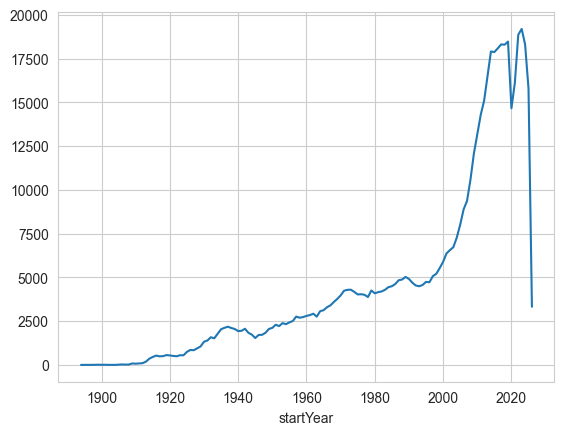

In [73]:
import matplotlib.pyplot as plt

films_par_an.plot()
plt.show()

**Nous observons une augmentation globale du nombre de films produits au fil du temps. Une baisse significative est visible en 2020, probablement liée à la pandémie de COVID-19. Les données récentes, comme 2026, sont incomplètes, ce qui explique les valeurs plus faibles.**

## KPI 2 — Nombre de films par genre

In [74]:
films_par_genre = df['genres'].value_counts()
print(films_par_genre.head(10))

genres
Drama          155441
Comedy          82225
Documentary     55991
Romance         37159
Action          35090
Crime           29674
Thriller        29217
Horror          26609
Adventure       20721
Mystery         13545
Name: count, dtype: int64


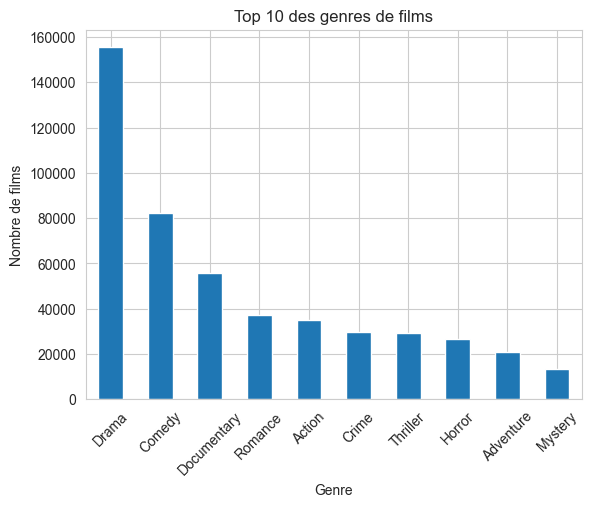

In [75]:
import matplotlib.pyplot as plt

films_par_genre.head(10).plot(kind='bar')
plt.title("Top 10 des genres de films")
plt.xlabel("Genre")
plt.ylabel("Nombre de films")
plt.xticks(rotation=45)
plt.show()

**L’analyse montre une forte dominance du genre Drama, suivi par Comedy et Documentary. Cela indique que les films dramatiques sont les plus produits, probablement en raison de leur flexibilité narrative et de leur popularité auprès du public.**

## KPI 3 : Évolution des genres dans le temps

In [76]:
evolution = df.groupby(['startYear', 'genres']).size().unstack().fillna(0)

In [77]:
print(evolution.head())

genres     Action  Adult  Adventure  Animation  Biography  Comedy  Crime  \
startYear                                                                  
1894          0.0    0.0        0.0        0.0        0.0     0.0    0.0   
1896          0.0    0.0        0.0        0.0        0.0     0.0    0.0   
1897          0.0    0.0        0.0        0.0        0.0     0.0    0.0   
1898          0.0    0.0        0.0        0.0        0.0     0.0    0.0   
1899          0.0    0.0        0.0        0.0        0.0     0.0    0.0   

genres     Documentary  Drama  Family  ...  Mystery  News  Reality-TV  \
startYear                              ...                              
1894               0.0    0.0     0.0  ...      0.0   0.0         0.0   
1896               1.0    0.0     0.0  ...      0.0   0.0         0.0   
1897               2.0    0.0     0.0  ...      0.0   2.0         0.0   
1898               6.0    0.0     0.0  ...      0.0   0.0         0.0   
1899               8.0    0.0

In [78]:
top_genres = df['genres'].value_counts().head(5).index

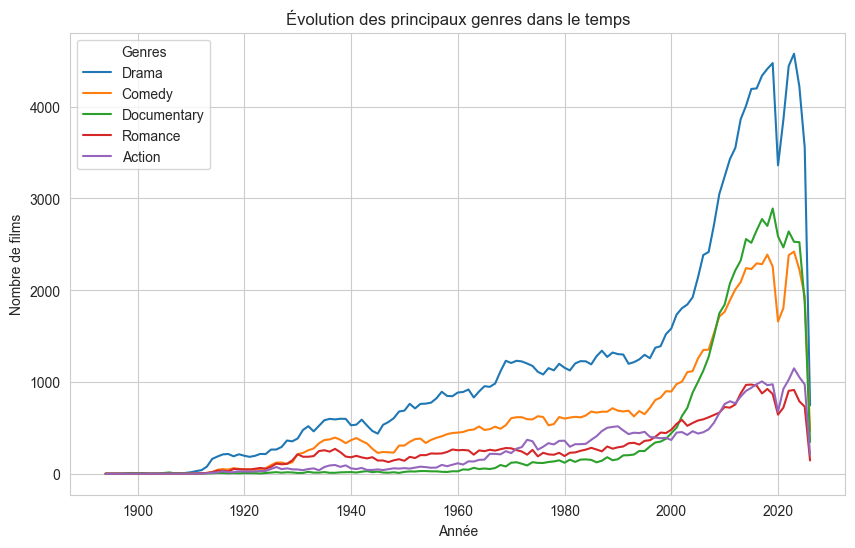

In [79]:
import matplotlib.pyplot as plt

evolution[top_genres].plot(figsize=(10,6))

plt.title("Évolution des principaux genres dans le temps")
plt.xlabel("Année")
plt.ylabel("Nombre de films")
plt.legend(title="Genres")

plt.show()

**Ce graphique montre l’évolution des principaux genres dans le temps. On observe une croissance globale, avec une dominance du genre Drama.**

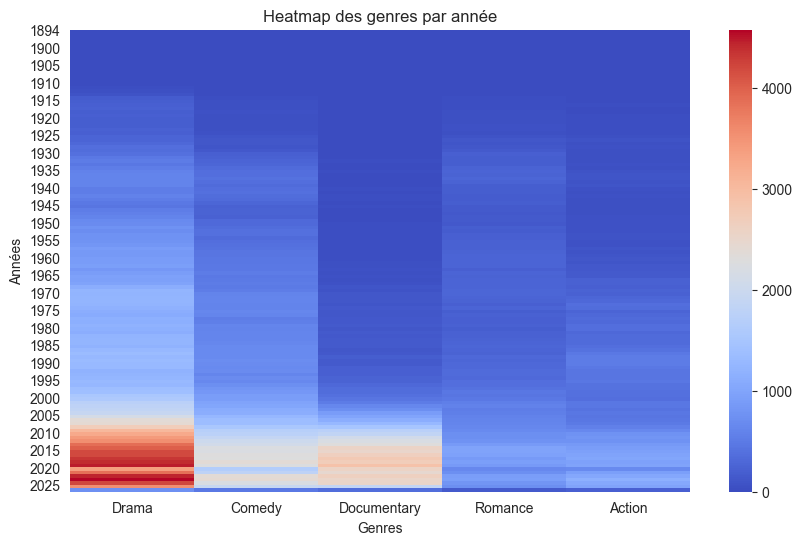

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

# réduire les données pour lisibilité
top_genres = df['genres'].value_counts().head(5).index
data_heatmap = evolution[top_genres]

plt.figure(figsize=(10,6))
sns.heatmap(data_heatmap, cmap="coolwarm")

plt.title("Heatmap des genres par année")
plt.xlabel("Genres")
plt.ylabel("Années")

plt.show()

Créer une base spéciale recommandation

In [81]:
df_rec = df.copy()

df_rec = df_rec.dropna(subset=['primaryTitle', 'genres', 'averageRating', 'numVotes'])
df_rec = df_rec[df_rec['titleType'] == 'movie']
df_rec = df_rec[df_rec['numVotes'] >= 1000]
df_rec = df_rec.reset_index(drop=True)

Note pondérée

In [82]:
C = df_rec['averageRating'].mean()
m = df_rec['numVotes'].quantile(0.90)

df_rec['weighted_rating'] = (
    (df_rec['numVotes'] / (df_rec['numVotes'] + m)) * df_rec['averageRating']
    + (m / (df_rec['numVotes'] + m)) * C
)

Récupération des synopsis avec TMDb

In [83]:
import requests

API_KEY = "ab6db99fb693b7633c8e7ecdfc67287d"

imdb_id = "tt1375666"  # Inception

url = f"https://api.themoviedb.org/3/find/{imdb_id}"

params = {
    "api_key": API_KEY,
    "external_source": "imdb_id",
    "language": "en-US"
}

response = requests.get(url, params=params)
data = response.json()

print(data)

{'movie_results': [{'adult': False, 'backdrop_path': '/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg', 'id': 27205, 'title': 'Inception', 'original_title': 'Inception', 'overview': 'Cobb, a skilled thief who commits corporate espionage by infiltrating the subconscious of his targets is offered a chance to regain his old life as payment for a task considered to be impossible: "inception", the implantation of another person\'s idea into a target\'s subconscious.', 'poster_path': '/xlaY2zyzMfkhk0HSC5VUwzoZPU1.jpg', 'media_type': 'movie', 'original_language': 'en', 'genre_ids': [28, 878, 12], 'popularity': 54.1693, 'release_date': '2010-07-15', 'softcore': False, 'video': False, 'vote_average': 8.373, 'vote_count': 40109}], 'person_results': [], 'tv_results': [], 'tv_episode_results': [], 'tv_season_results': []}


In [84]:
movie = data["movie_results"][0]

print("Titre :", movie["title"])
print("Synopsis :", movie["overview"])

Titre : Inception
Synopsis : Cobb, a skilled thief who commits corporate espionage by infiltrating the subconscious of his targets is offered a chance to regain his old life as payment for a task considered to be impossible: "inception", the implantation of another person's idea into a target's subconscious.


In [85]:
def get_synopsis(imdb_id):
    url = f"https://api.themoviedb.org/3/find/{imdb_id}"

    params = {
        "api_key": API_KEY,
        "external_source": "imdb_id",
        "language": "en-US"
    }

    response = requests.get(url, params=params)
    data = response.json()

    if data["movie_results"]:
        return data["movie_results"][0]["overview"]

    return None

In [86]:
print(get_synopsis("tt1375666"))

Cobb, a skilled thief who commits corporate espionage by infiltrating the subconscious of his targets is offered a chance to regain his old life as payment for a task considered to be impossible: "inception", the implantation of another person's idea into a target's subconscious.


In [87]:
df_test = df_rec.head(10).copy()

df_test["synopsis"] = df_test["tconst"].apply(get_synopsis)

df_test[
    ["tconst", "primaryTitle", "genres", "synopsis"]
]

,tconst,primaryTitle,genres,synopsis
0,tt0000574,The Story of the Kelly Gang,Action,Just as Galeen and Wegener's Der Golem (1915) ...
1,tt0000574,The Story of the Kelly Gang,Adventure,Just as Galeen and Wegener's Der Golem (1915) ...
2,tt0000574,The Story of the Kelly Gang,Biography,Just as Galeen and Wegener's Der Golem (1915) ...
3,tt0002130,Dante's Inferno,Adventure,The classic tale of Dante's journey through he...
4,tt0002130,Dante's Inferno,Drama,The classic tale of Dante's journey through he...
5,tt0002130,Dante's Inferno,Fantasy,The classic tale of Dante's journey through he...
6,tt0002423,Passion,Biography,"The story of Madame DuBarry, the mistress of L..."
7,tt0002423,Passion,Drama,"The story of Madame DuBarry, the mistress of L..."
8,tt0002423,Passion,Romance,"The story of Madame DuBarry, the mistress of L..."
9,tt0002844,Fantômas: In the Shadow of the Guillotine,Crime,NaN


In [88]:
# Regrouper les genres pour avoir une seule ligne par film
df_rec_clean = (
    df_rec.groupby(
        ['tconst', 'primaryTitle', 'startYear', 'averageRating', 'numVotes', 'weighted_rating'],
        as_index=False
    )
    .agg({
        'genres': lambda x: ','.join(sorted(set(x)))
    })
)

df_rec_clean.head()

,tconst,primaryTitle,startYear,averageRating,numVotes,weighted_rating,genres
0,tt0000574,The Story of the Kelly Gang,1906,6.0,1070,6.219356,"Action,Adventure,Biography"
1,tt0002130,Dante's Inferno,1911,7.1,4114,6.282738,"Adventure,Drama,Fantasy"
2,tt0002423,Passion,1919,6.7,1129,6.232787,"Biography,Drama,Romance"
3,tt0002844,Fantômas: In the Shadow of the Guillotine,1913,6.9,2722,6.254455,"Crime,Drama"
4,tt0003014,Ingeborg Holm,1913,7.0,1604,6.244836,Drama


In [89]:
df_test = df_rec_clean.head(10).copy()

df_test['synopsis'] = df_test['tconst'].apply(get_synopsis)

df_test[
    ['tconst', 'primaryTitle', 'genres', 'synopsis']
]

,tconst,primaryTitle,genres,synopsis
0,tt0000574,The Story of the Kelly Gang,"Action,Adventure,Biography",Just as Galeen and Wegener's Der Golem (1915) ...
1,tt0002130,Dante's Inferno,"Adventure,Drama,Fantasy",The classic tale of Dante's journey through he...
2,tt0002423,Passion,"Biography,Drama,Romance","The story of Madame DuBarry, the mistress of L..."
3,tt0002844,Fantômas: In the Shadow of the Guillotine,"Crime,Drama",NaN
4,tt0003014,Ingeborg Holm,Drama,After Ingeborg Holm's husband becomes sick and...
5,tt0003037,Fantomas: The Man in Black,"Crime,Drama",NaN
6,tt0003165,Fantômas: The Dead Man Who Killed,"Crime,Drama,Mystery",NaN
7,tt0003419,The Student of Prague,"Drama,Fantasy,Horror","Prague, Bohemia, 1820. Balduin, a penniless st..."
8,tt0003643,The Avenging Conscience: or 'Thou Shalt Not Kill',"Crime,Drama,Horror",Thwarted by his despotic uncle from continuing...
9,tt0003740,Cabiria,"Adventure,Drama,History",Young Cabiria is kidnapped by pirates and sold...


In [90]:
print("Tous les films :", len(df_rec_clean))
print("≥ 1 000 votes :", len(df_rec_clean[df_rec_clean['numVotes'] >= 1000]))
print("≥ 5 000 votes :", len(df_rec_clean[df_rec_clean['numVotes'] >= 5000]))
print("≥ 10 000 votes :", len(df_rec_clean[df_rec_clean['numVotes'] >= 10000]))

Tous les films : 48183
≥ 1 000 votes : 48183
≥ 5 000 votes : 18764
≥ 10 000 votes : 12374


In [91]:
df_final = df_rec_clean[
    df_rec_clean['numVotes'] >= 10000
].copy()

df_final = df_final.reset_index(drop=True)

print("Nombre de films retenus :", len(df_final))

Nombre de films retenus : 12374


### Sélection des films pour le moteur de recommandation

Afin de conserver des films suffisamment représentatifs, nous retenons les films ayant au moins 10 000 votes.

**Récupération des synopsis**

In [92]:
import requests
import time

def get_synopsis(imdb_id):
    url = f"https://api.themoviedb.org/3/find/{imdb_id}"

    params = {
        "api_key": API_KEY,
        "external_source": "imdb_id",
        "language": "en-US"
    }

    try:
        response = requests.get(url, params=params, timeout=10)

        if response.status_code == 200:
            data = response.json()

            if data.get("movie_results"):
                return data["movie_results"][0].get("overview", "")

        return ""

    except requests.RequestException:
        return ""

In [93]:
df_final["synopsis"] = ""

In [94]:
#Récupère les synopsis progressivement
for i in range(len(df_final)):

    imdb_id = df_final.loc[i, "tconst"]

    df_final.loc[i, "synopsis"] = get_synopsis(imdb_id)

    # Sauvegarde tous les 100 films
    if (i + 1) % 100 == 0:
        df_final.to_csv(
            "filmcity_recommendation.csv",
            index=False
        )

        print(f"{i + 1} / {len(df_final)} films traités")

    # Petite pause entre les requêtes
    time.sleep(0.05)

# Sauvegarde finale
df_final.to_csv(
    "filmcity_recommendation.csv",
    index=False
)

print("Terminé !")

100 / 12374 films traités
200 / 12374 films traités
300 / 12374 films traités
400 / 12374 films traités
500 / 12374 films traités
600 / 12374 films traités
700 / 12374 films traités
800 / 12374 films traités
900 / 12374 films traités
1000 / 12374 films traités
1100 / 12374 films traités
1200 / 12374 films traités
1300 / 12374 films traités
1400 / 12374 films traités
1500 / 12374 films traités
1600 / 12374 films traités
1700 / 12374 films traités
1800 / 12374 films traités
1900 / 12374 films traités
2000 / 12374 films traités
2100 / 12374 films traités
2200 / 12374 films traités
2300 / 12374 films traités
2400 / 12374 films traités
2500 / 12374 films traités
2600 / 12374 films traités
2700 / 12374 films traités
2800 / 12374 films traités
2900 / 12374 films traités
3000 / 12374 films traités
3100 / 12374 films traités
3200 / 12374 films traités
3300 / 12374 films traités
3400 / 12374 films traités
3500 / 12374 films traités
3600 / 12374 films traités
3700 / 12374 films traités
3800 / 123

In [95]:
nb_synopsis = (df_final["synopsis"].str.len() > 0).sum()

print("Synopsis récupérés :", nb_synopsis)
print("Total films :", len(df_final))
print("Pourcentage :", round(nb_synopsis / len(df_final) * 100, 2), "%")

Synopsis récupérés : 12371
Total films : 12374
Pourcentage : 99.98 %


In [96]:
df_final = df_final[
    df_final["synopsis"].str.len() > 0
].copy()

df_final = df_final.reset_index(drop=True)

print("Films conservés :", len(df_final))

Films conservés : 12371


### Création des caractéristiques pour la recommandation

Combinaison des genres et du synopsis afin de mesurer la similarité entre les films.

Features

In [97]:
df_final["features"] = (
    (df_final["genres"].fillna("") + " ") * 3
    + df_final["synopsis"].fillna("")
)

In [98]:
# Features texte = synopsis uniquement
df_final["features"] = df_final["synopsis"].fillna("")

### Vectorisation des caractéristiques avec TF-IDF

Transformation des genres et synopsis en données numériques afin de comparer les films.

Vectoriser + calculer similarité cosinus

In [99]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

In [113]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=10000
)

tfidf_matrix = vectorizer.fit_transform(
    df_final["features"]
)

### Calcul de la similarité des genres

In [101]:
def genre_similarity(genres_a, genres_b):
    set_a = set(genres_a.split(","))
    set_b = set(genres_b.split(","))

    if not set_a or not set_b:
        return 0

    return len(set_a & set_b) / len(set_a | set_b)

In [103]:
def recommend_movie(title, mode="equilibre", n=10):

    # Trouver le film choisi
    matches = df_final[
        df_final["primaryTitle"].str.lower() == title.lower()
    ]

    if matches.empty:
        return "Film introuvable"

    idx = matches.index[0]

    # Genres du film sélectionné
    selected_genres = df_final.loc[idx, "genres"]

    # Similarité des synopsis
    scores = cosine_similarity(
        tfidf_matrix[idx],
        tfidf_matrix
    ).flatten()

    recommendations = df_final.copy()
    recommendations["similarity_score"] = scores

    # Retirer le film choisi
    recommendations = recommendations[
        recommendations.index != idx
    ].copy()

    # Similarité des genres
    recommendations["genre_score"] = recommendations["genres"].apply(
        lambda x: genre_similarity(selected_genres, x)
    )

    # Garder un minimum de proximité du synopsis
    recommendations = recommendations[
        recommendations["similarity_score"] >= 0.03
    ].copy()

    # Choix du mode
    if mode == "similaire":
        poids_synopsis = 0.55
        poids_genres = 0.40
        poids_qualite = 0.05

    recommendations = recommendations[
        recommendations["genre_score"] >= 0.5
    ].copy()

    elif mode == "qualite":
        poids_synopsis = 0.40
        poids_genres = 0.20
        poids_qualite = 0.40

    elif mode == "decouverte":
        poids_synopsis = 0.40
        poids_genres = 0.45
        poids_qualite = 0.15

        recommendations = recommendations[
            (recommendations["numVotes"] >= 10000) &
            (recommendations["numVotes"] <= 300000) &
            (recommendations["weighted_rating"] >= 6.5) &
            (recommendations["genre_score"] >= 0.5)
        ].copy()

    else:  # mode équilibré
        poids_synopsis = 0.55
        poids_genres = 0.25
        poids_qualite = 0.20

    # Score final
    recommendations["recommendation_score"] = (
        poids_synopsis * recommendations["similarity_score"]
        + poids_genres * recommendations["genre_score"]
        + poids_qualite * recommendations["rating_normalized"]
    )

    # Classement final
    recommendations = recommendations.sort_values(
        "recommendation_score",
        ascending=False
    )

    # Résultat
    return recommendations[
        [
            "primaryTitle",
            "genres",
            "startYear",
            "averageRating",
            "numVotes",
            "weighted_rating",
            "similarity_score",
            "genre_score",
            "recommendation_score"
        ]
    ].head(n)

### Normalisation de la note pondérée

Normalisation de la note pondérée entre 0 et 1 afin de pouvoir la combiner avec le score de similarité dans le calcul du score final de recommandation.

In [106]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_final["rating_normalized"] = scaler.fit_transform(
    df_final[["weighted_rating"]]
)

In [107]:
df_final[
    ["primaryTitle", "weighted_rating", "rating_normalized"]
].head()

,primaryTitle,weighted_rating,rating_normalized
0,The Birth of a Nation,6.182426,0.531623
1,Intolerance,6.554232,0.588464
2,Broken Blossoms,6.391373,0.563567
3,The Cabinet of Dr. Caligari,7.241621,0.693552
4,The Kid,7.645563,0.755307


### Évaluation du moteur de recommandation

In [108]:
print("=== MÊME VIBE ===")
display(recommend_movie("Toy Story", mode="similaire", n=5))

print("=== POUR TOI ===")
display(recommend_movie("Toy Story", mode="equilibre", n=5))

print("=== LES INCONTOURNABLES ===")
display(recommend_movie("Toy Story", mode="qualite", n=5))

print("=== PÉPITE À DÉCOUVRIR ===")
display(recommend_movie("Toy Story", mode="decouverte", n=5))

=== MÊME VIBE ===


,primaryTitle,genres,startYear,averageRating,numVotes,weighted_rating,similarity_score,genre_score,recommendation_score
5465,Toy Story 3,"Adventure,Animation,Comedy",2010,8.3,968594,8.185071,0.539479,1.00,0.669525
3437,Toy Story 2,"Adventure,Animation,Comedy",1999,7.9,669146,7.768932,0.461452,1.00,0.611725
8928,Toy Story 4,"Adventure,Animation,Comedy",2019,7.6,313995,7.389298,0.291523,1.00,0.489873
8320,Free Birds,"Adventure,Animation,Comedy",2013,5.8,28443,6.082102,0.087190,1.00,0.336847
5232,The 40-Year-Old Virgin,"Comedy,Romance",2005,7.1,500896,7.010801,0.329118,0.25,0.325796


=== POUR TOI ===


,primaryTitle,genres,startYear,averageRating,numVotes,weighted_rating,similarity_score,genre_score,recommendation_score
5465,Toy Story 3,"Adventure,Animation,Comedy",2010,8.3,968594,8.185071,0.539479,1.0,0.714271
3437,Toy Story 2,"Adventure,Animation,Comedy",1999,7.9,669146,7.768932,0.461452,1.0,0.658632
8928,Toy Story 4,"Adventure,Animation,Comedy",2019,7.6,313995,7.389298,0.291523,1.0,0.553564
5178,Tangled,"Adventure,Animation,Comedy",2010,7.7,544467,7.560630,0.049620,1.0,0.425756
8320,Free Birds,"Adventure,Animation,Comedy",2013,5.8,28443,6.082102,0.087190,1.0,0.401211


=== LES INCONTOURNABLES ===


,primaryTitle,genres,startYear,averageRating,numVotes,weighted_rating,similarity_score,genre_score,recommendation_score
5465,Toy Story 3,"Adventure,Animation,Comedy",2010,8.3,968594,8.185071,0.539479,1.0,0.750907
3437,Toy Story 2,"Adventure,Animation,Comedy",1999,7.9,669146,7.768932,0.461452,1.0,0.694248
8928,Toy Story 4,"Adventure,Animation,Comedy",2019,7.6,313995,7.389298,0.291523,1.0,0.603061
5178,Tangled,"Adventure,Animation,Comedy",2010,7.7,544467,7.560630,0.049620,1.0,0.516777
5799,The Croods,"Adventure,Animation,Comedy",2013,7.1,251276,6.938515,0.036972,1.0,0.473674


=== PÉPITE À DÉCOUVRIR ===


,primaryTitle,genres,startYear,averageRating,numVotes,weighted_rating,similarity_score,genre_score,recommendation_score
5799,The Croods,"Adventure,Animation,Comedy",2013,7.1,251276,6.938515,0.036972,1.000000,0.561871
9959,The Croods: A New Age,"Adventure,Animation,Comedy",2020,6.9,61212,6.574541,0.037139,1.000000,0.553591
9128,The 100 Year-Old Man Who Climbed Out the Windo...,"Adventure,Comedy",2013,7.0,44233,6.563622,0.035727,0.666667,0.402776
10978,Hunt for the Wilderpeople,"Adventure,Comedy,Drama",2016,7.8,152938,7.373335,0.066069,0.500000,0.358481
10884,Paddington 2,"Adventure,Comedy,Family",2017,7.8,113814,7.275466,0.038306,0.500000,0.345131


In [109]:
recommend_movie("The Godfather", mode="equilibre", n=10)

,primaryTitle,genres,startYear,averageRating,numVotes,weighted_rating,similarity_score,genre_score,recommendation_score
1086,The Godfather Part II,"Crime,Drama",1974,9.0,1493608,8.898368,0.446217,1.0,0.684786
2291,The Godfather Part III,"Crime,Drama",1990,7.5,455193,7.358497,0.171017,1.0,0.486344
2877,Pulp Fiction,"Crime,Drama",1994,8.8,2432279,8.741256,0.035829,1.0,0.454269
4613,City of God,"Crime,Drama",2002,8.6,869941,8.454465,0.038315,1.0,0.446867
3453,American History X,"Crime,Drama",1998,8.5,1272011,8.402773,0.037055,1.0,0.444594
2445,Mobsters,"Crime,Drama",1991,5.9,10312,6.173749,0.133448,1.0,0.429456
7493,Joji,"Crime,Drama",2021,7.7,12819,6.495559,0.099056,1.0,0.420380
2180,Family Business,"Crime,Drama",1989,5.8,14917,6.135345,0.118136,1.0,0.419860
2386,Boyz n the Hood,"Crime,Drama",1991,7.8,168424,7.402678,0.041743,1.0,0.416593
2642,A Bronx Tale,"Crime,Drama",1993,7.8,185074,7.430034,0.035621,1.0,0.414063


In [110]:
recommend_movie("american psycho", mode="equilibre", n=10)

,primaryTitle,genres,startYear,averageRating,numVotes,weighted_rating,similarity_score,genre_score,recommendation_score
1396,Maniac,"Crime,Drama,Horror",1980,6.3,22360,6.245116,0.055437,1.000000,0.388732
7073,Orphan: First Kill,"Crime,Drama,Horror",2022,5.9,53975,6.065799,0.039506,1.000000,0.374487
7541,The Resident,"Crime,Drama,Horror",2011,5.3,30631,5.899765,0.045602,1.000000,0.372763
2944,Casino,"Crime,Drama",1995,8.2,618672,8.033931,0.076369,0.666667,0.371606
7040,A Nightmare on Elm Street,"Crime,Drama,Horror",2010,5.2,114918,5.538345,0.030971,1.000000,0.353665
1198,Taxi Driver,"Crime,Drama",1976,8.2,1025008,8.096311,0.037669,0.666667,0.352228
11799,Joker,"Crime,Drama,Thriller",2019,8.3,1690785,8.232567,0.093738,0.500000,0.345566
845,Rosemary's Baby,"Drama,Horror",1968,8.0,257669,7.679356,0.046798,0.666667,0.344500
2291,The Godfather Part III,"Crime,Drama",1990,7.5,455193,7.358497,0.038240,0.666667,0.329983
5788,This Is England,"Crime,Drama",2006,7.7,135036,7.263098,0.036590,0.666667,0.326158


In [112]:
resultat = recommend_movie("american psycho", mode="equilibre", n=10)
print(resultat["similarity_score"].min())

0.03097143159627871


In [111]:
display(recommend_movie("Toy Story", mode="decouverte", n=5))

,primaryTitle,genres,startYear,averageRating,numVotes,weighted_rating,similarity_score,genre_score,recommendation_score
5799,The Croods,"Adventure,Animation,Comedy",2013,7.1,251276,6.938515,0.036972,1.000000,0.561871
9959,The Croods: A New Age,"Adventure,Animation,Comedy",2020,6.9,61212,6.574541,0.037139,1.000000,0.553591
9128,The 100 Year-Old Man Who Climbed Out the Windo...,"Adventure,Comedy",2013,7.0,44233,6.563622,0.035727,0.666667,0.402776
10978,Hunt for the Wilderpeople,"Adventure,Comedy,Drama",2016,7.8,152938,7.373335,0.066069,0.500000,0.358481
10884,Paddington 2,"Adventure,Comedy,Family",2017,7.8,113814,7.275466,0.038306,0.500000,0.345131


In [53]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.
